# 🚢 Titanic - Machine Learning from Disaster

Competición de Kaggle: predecir qué pasajeros sobrevivieron al hundimiento del Titanic.

**Métrica:** Accuracy  
**Tipo:** Clasificación binaria  
**Enlace:** https://www.kaggle.com/competitions/titanic

Imports necesarios para el desarrollo del proyecto

In [1]:
# ==================================================
# Imports del proyecto Titanic
# ==================================================

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Validación y selección de modelos
from sklearn.model_selection import (cross_val_score, StratifiedKFold, 
                                      RepeatedStratifiedKFold, train_test_split)

# Modelos clásicos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)

# Modelos avanzados
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Tuning
import optuna

# Configuración
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Todos los imports cargados correctamente")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Estilo de los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

✅ Todos los imports cargados correctamente


/Users/caneda/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga de datos

In [2]:
train = pd.read_csv('../Titanic_Competition/train.csv')
test = pd.read_csv('../Titanic_Competition/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Exploración inicial

Queremos entender: estructura de las columnas, tipos de datos, valores nulos y la distribución del target.

In [3]:
train.info()
# Valores nulos en train y test
nulls = pd.DataFrame({
    'train_nulls': train.isnull().sum(),
    'train_pct':   (train.isnull().sum() / len(train) * 100).round(2),
    'test_nulls':  test.isnull().sum().reindex(train.columns, fill_value=0),
})
nulls[nulls['train_nulls'] > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,train_nulls,train_pct,test_nulls
Age,177,19.87,86
Cabin,687,77.10,327
Embarked,2,0.22,0


Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


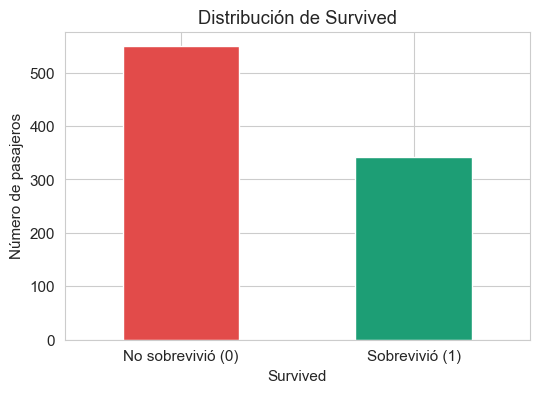

In [4]:
print(train['Survived'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
train['Survived'].value_counts().plot(kind='bar', ax=ax, color=['#E24B4A', '#1D9E75'])
ax.set_title('Distribución de Survived')
ax.set_xticklabels(['No sobrevivió (0)', 'Sobrevivió (1)'], rotation=0)
ax.set_ylabel('Número de pasajeros')
plt.show()

De la gráfica concluimos que la caracteristica que en general es más probable no sobrevivir que sobrevivir ya que el 61,6% de las personas no consiguen sobrevivir y el 38,4% si. Esto es basado en los datos de entrenamiento.

## 3. EDA - Análisis de cada variable vs Survived

            mean  count
Sex                    
female  0.742038    314
male    0.188908    577


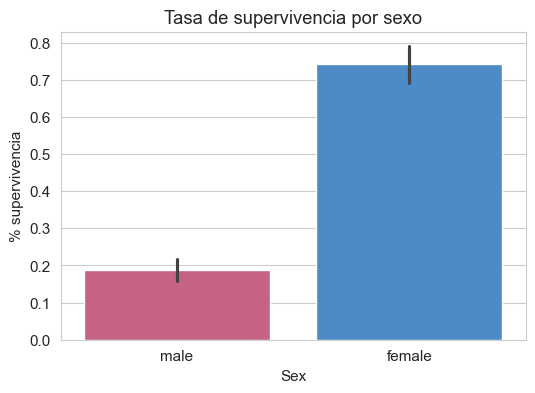

In [5]:
# Supervivencia por sexo
print(train.groupby('Sex')['Survived'].agg(['mean', 'count']))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=train, x='Sex', y='Survived', ax=ax, palette=['#D4537E', '#378ADD'])
ax.set_title('Tasa de supervivencia por sexo')
ax.set_ylabel('% supervivencia')
plt.show()

Ser mujer aumenta de forma significativa las probabilidades de sobrevivir. 

            mean  count
Pclass                 
1       0.629630    216
2       0.472826    184
3       0.242363    491


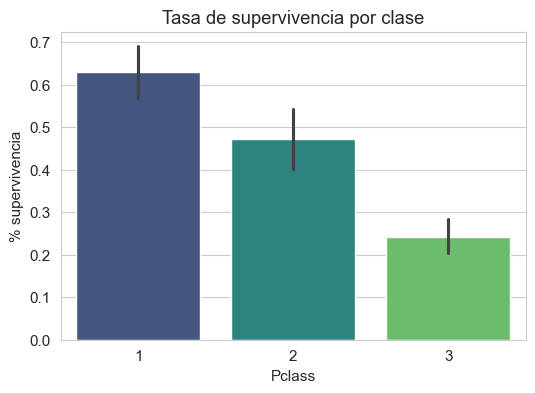

In [6]:
# Supervivencia por clase
print(train.groupby('Pclass')['Survived'].agg(['mean', 'count']))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=train, x='Pclass', y='Survived', ax=ax, palette='viridis')
ax.set_title('Tasa de supervivencia por clase')
ax.set_ylabel('% supervivencia')
plt.show()

El factor Pclass es un factor determinante a la hora de predecir la supervivencia de un pasajero. Los de mayor clase, mayor probabilidad tienen de sobrevivir. 

Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


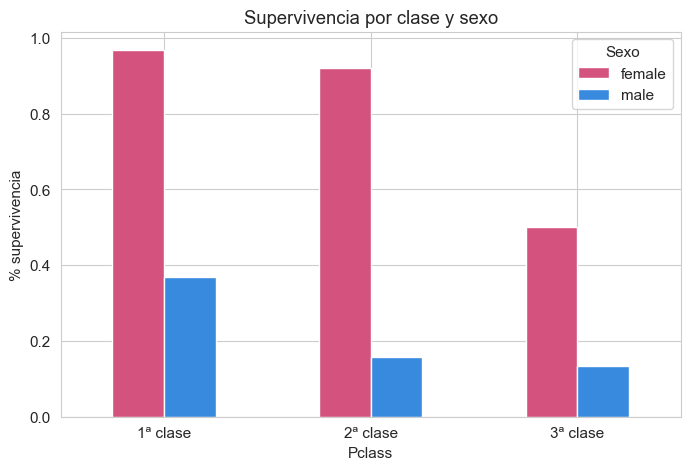

In [7]:
# Supervivencia por sexo + clase
pivot = train.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().round(3)
print(pivot)

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax, color=['#D4537E', '#378ADD'])
ax.set_title('Supervivencia por clase y sexo')
ax.set_ylabel('% supervivencia')
ax.set_xticklabels(['1ª clase', '2ª clase', '3ª clase'], rotation=0)
ax.legend(title='Sexo')
plt.show()

Esta combinación de factores es clave para determinar la supervivencia de un pasajero. La grafica nos ayuda a entender como varía tu probabilidad de sobrevivir según tu clase y sexo. Como vemos el factor más determinante es el sexo. 

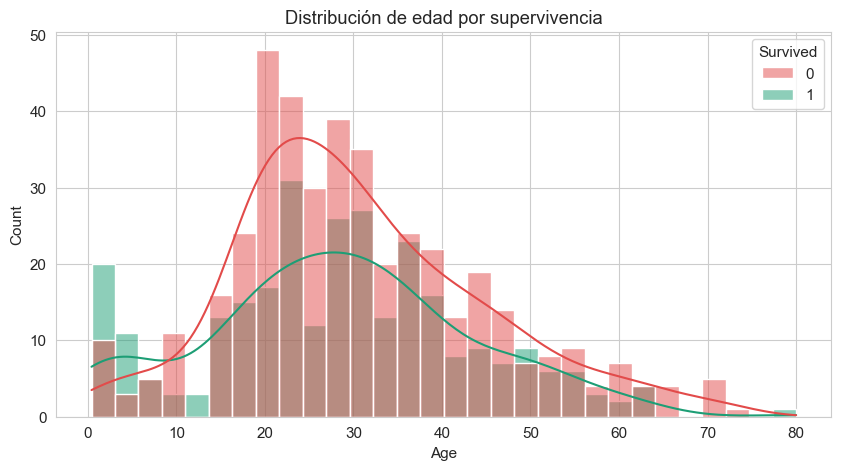

Niños (<16 años) vs adultos:
             mean  count
IsChild                 
0        0.362624    808
1        0.590361     83


In [8]:
# Distribución de edad por supervivencia
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=train, x='Age', hue='Survived', bins=30, kde=True, ax=ax, palette=['#E24B4A', '#1D9E75'])
ax.set_title('Distribución de edad por supervivencia')
plt.show()

# Niños vs adultos
train['IsChild'] = (train['Age'] < 16).astype(int)
print("Niños (<16 años) vs adultos:")
print(train.groupby('IsChild')['Survived'].agg(['mean', 'count']))

De la grafica de distribución por edad podemos concluir que solo los niños menores de 16 años tienen más probabilidad de sobrevivir de que no. El resto, los adultos, es más probable que no sobrevivan.

              mean  count
Embarked                 
C         0.553571    168
Q         0.389610     77
S         0.336957    644


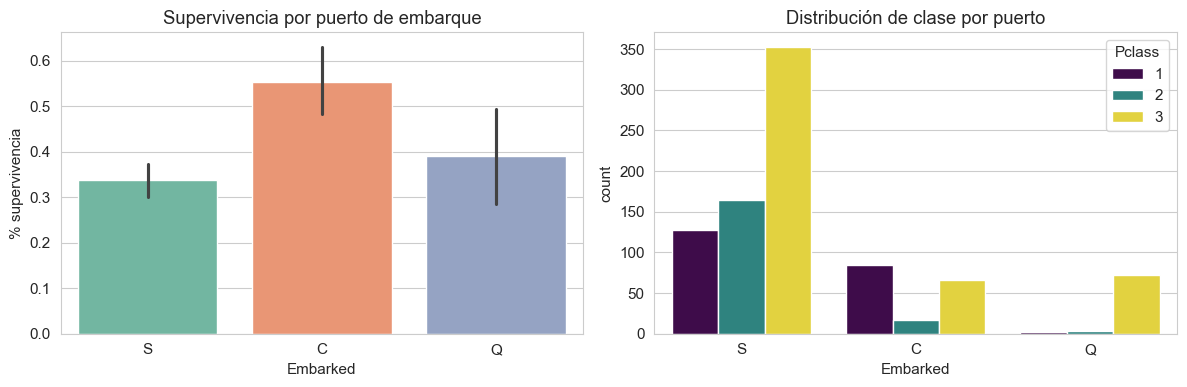

In [9]:
# Supervivencia por puerto de embarque
print(train.groupby('Embarked')['Survived'].agg(['mean', 'count']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=train, x='Embarked', y='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Supervivencia por puerto de embarque')
axes[0].set_ylabel('% supervivencia')

sns.countplot(data=train, x='Embarked', hue='Pclass', ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de clase por puerto')
plt.tight_layout()
plt.show()

Tienen mayor probabilidad de supervivencia los que embarcaron en el puerto C, esto puede ser debido a que la mayoría de los que embarcaron eran pasajeros de primera clase, ya que en el embarque Q eran casi todos de tercera y en el S la mayoría también eran de tercera.

          count   mean    std  min    25%   50%   75%     max
Survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


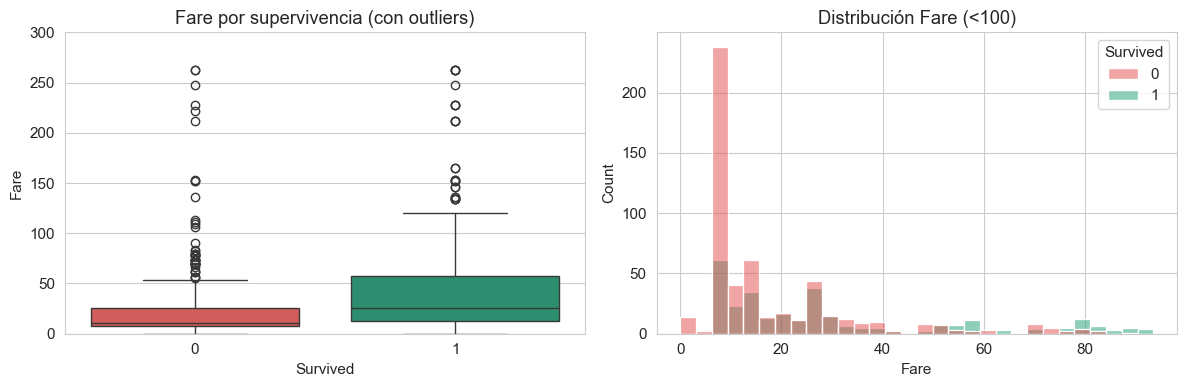

In [10]:
# Supervivencia por tarifa de embarque
print(train.groupby('Survived')['Fare'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=train, x='Survived', y='Fare', ax=axes[0], palette=['#E24B4A', '#1D9E75'])
axes[0].set_title('Fare por supervivencia (con outliers)')
axes[0].set_ylim(0, 300)  # limitar para verlo mejor

sns.histplot(data=train[train['Fare'] < 100], x='Fare', hue='Survived',
             bins=30, ax=axes[1], palette=['#E24B4A', '#1D9E75'])
axes[1].set_title('Distribución Fare (<100)')
plt.tight_layout()
plt.show()

                mean  count
FamilySize                 
1           0.303538    537
2           0.552795    161
3           0.578431    102
4           0.724138     29
5           0.200000     15
6           0.136364     22
7           0.333333     12
8           0.000000      6
11          0.000000      7


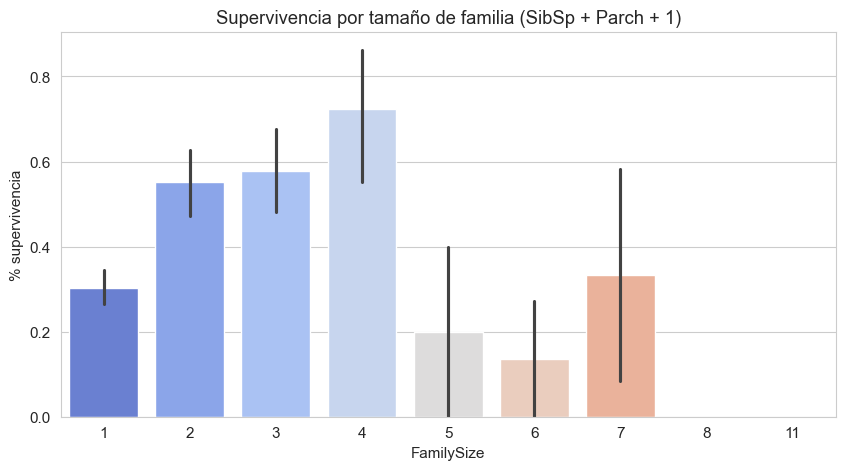

In [11]:
# Supervivencia por tamaño de la familia
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
print(train.groupby('FamilySize')['Survived'].agg(['mean', 'count']))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=train, x='FamilySize', y='Survived', ax=ax, palette='coolwarm')
ax.set_title('Supervivencia por tamaño de familia (SibSp + Parch + 1)')
ax.set_ylabel('% supervivencia')
plt.show()

No se puede concluir una tendencia clara con respecto al tamaño de la familia, parece ser que las familias de 4 tienen más probabilidades de sobrevivir pero no hay una clara relación con familias numerosas o de una sola persona.

                  mean  count
Title                        
Mr            0.156673    517
Miss          0.697802    182
Mrs           0.792000    125
Master        0.575000     40
Dr            0.428571      7
Rev           0.000000      6
Major         0.500000      2
Col           0.500000      2
Mlle          1.000000      2
Sir           1.000000      1
Ms            1.000000      1
Capt          0.000000      1
Mme           1.000000      1
Lady          1.000000      1
Jonkheer      0.000000      1
Don           0.000000      1
the Countess  1.000000      1


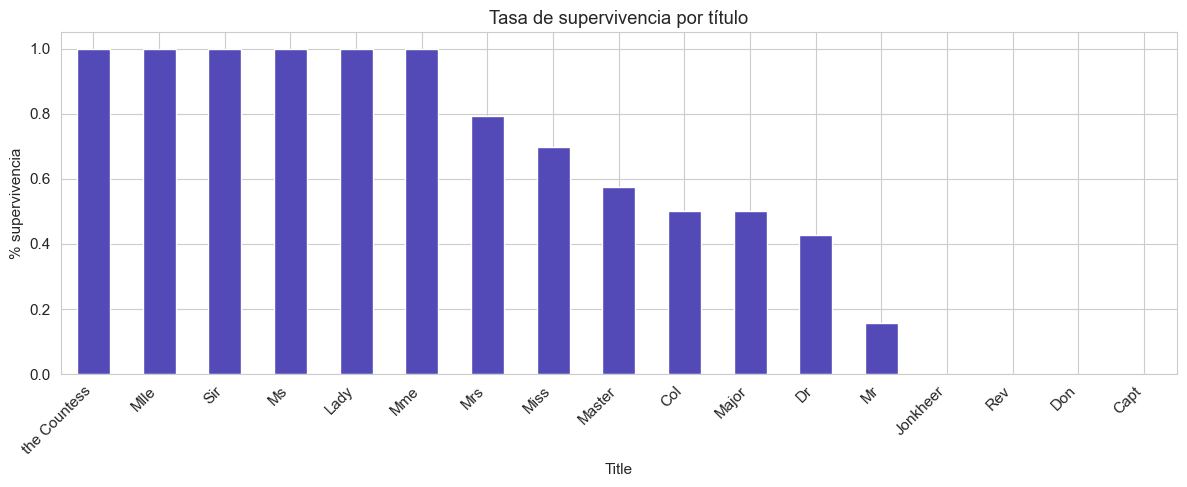

In [12]:
# Extraemos el título usando regex: busca coma, espacio, texto, punto
train['Title'] = train['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

print(train.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('count', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
title_survival = train.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_survival.plot(kind='bar', ax=ax, color='#534AB7')
ax.set_title('Tasa de supervivencia por título')
ax.set_ylabel('% supervivencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El título junta 3 variables claras, la edad, el sexo y el estatus por lo que el título es super determinante para el logaritmo. Como vemos hay títulos que determinan un 100% de probabilidades de sobrevivir, mientras que los peores tienen un 0% de probabilidades. La cuestión viene dada por los títulos intermedios, en los cuales tendremos una mayor dificultad para determinar la supervivencia del pasajero teniendo en cuenta otros factores. 

In [13]:
train['HasCabin'] = train['Cabin'].notna().astype(int)
print("¿Tiene cabina registrada?")
print(train.groupby('HasCabin')['Survived'].agg(['mean', 'count']))

# Primera letra = cubierta (deck)
train['Deck'] = train['Cabin'].str[0]
print("\nSupervivencia por cubierta:")
print(train.groupby('Deck')['Survived'].agg(['mean', 'count']))

¿Tiene cabina registrada?
              mean  count
HasCabin                 
0         0.299854    687
1         0.666667    204

Supervivencia por cubierta:
          mean  count
Deck                 
A     0.466667     15
B     0.744681     47
C     0.593220     59
D     0.757576     33
E     0.750000     32
F     0.615385     13
G     0.500000      4
T     0.000000      1


Concluimos que el no tener cabina es un factor relevante ya que en el modelo de entrenamiento el 66,67% de pasajeros que sobreviven tienen cabina.

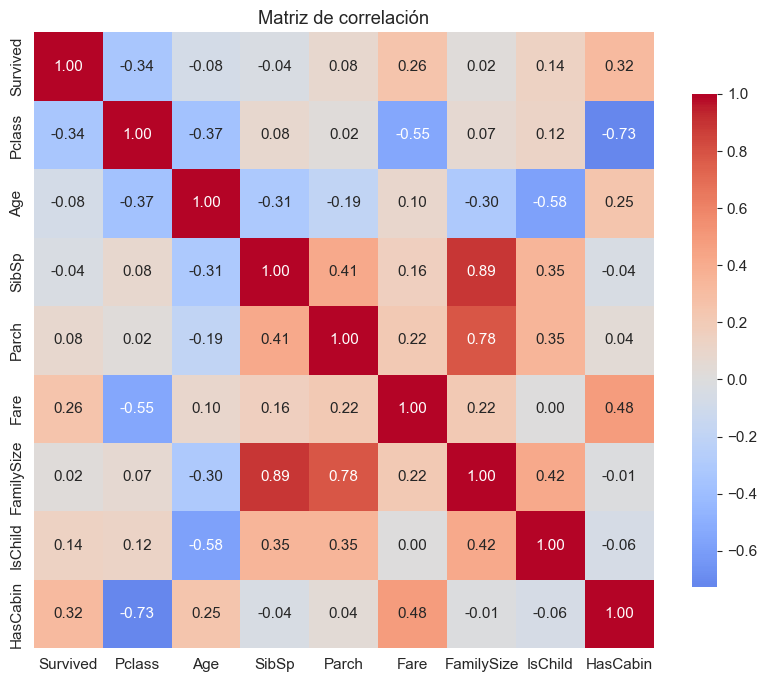

In [14]:
# Correlación entre variables numéricas y el target
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsChild', 'HasCabin']
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.show()

De la matriz de correlación no podemos sacar conclusiones claras, cada variable númerica es independiente del resto, menos las vaariables de FamilySize con Sibsp que si parecen tener una relación directa entre sí.

**3. Feature engineering

In [15]:
train['is_train'] = 1
test['is_train'] = 0
test['Survived'] = np.nan

full = pd.concat([train, test], axis=0, ignore_index=True)

In [16]:
full['Title'] = full['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)

El regex busca: después de una coma, captura todo hasta el punto. Así "Braund, Mr. Owen Harris" → Mr.
Luego agrupamos títulos raros para no tener categorías con 1-2 pasajeros (eso causa overfitting):

Mlle, Ms → Miss
Mme → Mrs
Dr, Rev, Col, Lady, Sir... → Rare

Resultado final: 5 categorías limpias (Mr, Miss, Mrs, Master, Rare).

In [17]:
# --- 2. Family features ---
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

# Definimos la función ANTES de usarla
def family_group(size):
    if size == 1:
        return 'Solo'
    elif size <= 4:
        return 'Small'
    else:
        return 'Large'

full['FamilyGroup'] = full['FamilySize'].apply(family_group)

Recuerda la U invertida del EDA: familias medianas (2-4) sobrevivían el 58%, pero solos (30%) o familias grandes (16%) iba peor. El bin captura esa no-linealidad.

In [18]:
full['HasCabin'] = full['Cabin'].notna().astype(int)
full['Deck'] = full['Cabin'].str[0].fillna('Unknown')

HasCabin: bandera de "tenía cabina registrada" (proxy de estatus).
Deck: la primera letra de la cabina (A, B, C...) indica la cubierta del barco. Las cubiertas superiores (A, B) eran de primera clase y estaban más cerca de los botes salvavidas.

Los 1014 nulos los marcamos como Unknown (es información en sí misma, no algo a imputar).

In [19]:
full['Age'] = full.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

In [20]:
full['AgeBin'] = pd.cut(full['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young', 'Adult', 'Senior'])
full['FareBin'] = pd.qcut(full['Fare'], q=4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High'])

In [21]:
ticket_counts = full['Ticket'].value_counts()
full['TicketGroupSize'] = full['Ticket'].map(ticket_counts)
full['FarePerPerson'] = full['Fare'] / full['TicketGroupSize']

In [22]:
# ===============================================
# Paso 3: Feature Engineering
# ===============================================

# Combinamos train y test para transformaciones consistentes
train['is_train'] = 1
test['is_train'] = 0
test['Survived'] = np.nan
full = pd.concat([train, test], axis=0, ignore_index=True)

# --- 1. Title ---
full['Title'] = full['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Capt': 'Rare', 'Sir': 'Rare', 'Lady': 'Rare', 'Don': 'Rare',
    'Dona': 'Rare', 'Jonkheer': 'Rare', 'the Countess': 'Rare'
}
full['Title'] = full['Title'].map(title_mapping)

# --- 2. Family features ---
full['FamilySize'] = full['SibSp'] + full['Parch'] + 1
full['IsAlone'] = (full['FamilySize'] == 1).astype(int)

def family_group(size):
    if size == 1: return 'Solo'
    elif size <= 4: return 'Small'
    else: return 'Large'

full['FamilyGroup'] = full['FamilySize'].apply(family_group)

# --- 3. Cabin / Deck ---
full['HasCabin'] = full['Cabin'].notna().astype(int)
full['Deck'] = full['Cabin'].str[0].fillna('Unknown')

# --- 4. Imputar Embarked (moda) ---
full['Embarked'] = full['Embarked'].fillna(full['Embarked'].mode()[0])

# --- 5. Imputar Fare (mediana por clase) ---
full['Fare'] = full.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# --- 6. Imputar Age (mediana por Title) ---
full['Age'] = full.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

# Feature: ¿es un niño?
full['IsChild'] = (full['Age'] < 16).astype(int)

# --- 7. Bins de Age y Fare ---
full['AgeBin'] = pd.cut(full['Age'], bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'Young', 'Adult', 'Senior'])
full['FareBin'] = pd.qcut(full['Fare'], q=4, labels=['Q1_Low', 'Q2', 'Q3', 'Q4_High'])

# --- 8. Ticket group ---
ticket_counts = full['Ticket'].value_counts()
full['TicketGroupSize'] = full['Ticket'].map(ticket_counts)

# --- 9. Fare per person ---
full['FarePerPerson'] = full['Fare'] / full['TicketGroupSize']

# Verificación
print("Nulos tras FE:", full.drop(columns=['Cabin', 'Survived']).isnull().sum().sum())
print("Shape final:", full.shape)
full.head()

Nulos tras FE: 0
Shape final: (1309, 24)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsChild,FamilySize,Title,HasCabin,Deck,is_train,IsAlone,FamilyGroup,AgeBin,FareBin,TicketGroupSize,FarePerPerson
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,2,Mr,0,Unknown,1,0,Small,Young,Q1_Low,1,7.25000
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,2,Mrs,1,C,1,0,Small,Adult,Q4_High,2,35.64165
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,Miss,0,Unknown,1,1,Solo,Young,Q2,1,7.92500
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,2,Mrs,1,C,1,0,Small,Young,Q4_High,2,26.55000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1,Mr,0,Unknown,1,1,Solo,Young,Q2,1,8.05000


📊 Resultados
ModeloAccuracy (media)Desviación📌 
Baseline ingenuo (todas mujeres)0.7868
Logistic Regression0.8283±0.013
Decision Tree (max_depth=5)0.8384±0.004
Random Forest0.8170±0.014🏆 
Gradient Boosting0.8417±0.020

EL MEJOR MODELO PARA ESTE CASO ES APLICAR GRADIENT BOOSTING

In [23]:
# ===============================================
# Paso 4: Modelos Baseline
# ===============================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Separar de nuevo train y test
train_df = full[full['is_train'] == 1].copy()
test_df  = full[full['is_train'] == 0].copy()

y = train_df['Survived'].astype(int)

drop_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin', 'is_train']
X_train = train_df.drop(columns=drop_cols)
X_test  = test_df.drop(columns=drop_cols)

# Identificar tipos de columnas
categorical_cols = ['Sex', 'Embarked', 'Title', 'FamilyGroup', 'Deck', 'AgeBin', 'FareBin']
numeric_cols = [c for c in X_train.columns if c not in categorical_cols]

# Preprocesador
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4 modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

# Evaluar todos
results = {}
print(f"{'Modelo':<22} | {'Accuracy':>10} | {'Std':>8}")
print("-" * 50)
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_val_score(pipe, X_train, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f"{name:<22} | {scores.mean():>10.4f} | {scores.std():>8.4f}")

# Baseline ingenuo de referencia
baseline_acc = ((train_df['Sex'] == 'female').astype(int) == y).mean()
print(f"\n📌 Baseline ingenuo (todas mujeres=1): {baseline_acc:.4f}")

Modelo                 |   Accuracy |      Std
--------------------------------------------------


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

Logistic Regression    |     0.8283 |   0.0127
Decision Tree          |     0.8395 |   0.0078


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest          |     0.8159 |   0.0112
Gradient Boosting      |     0.8417 |   0.0198

📌 Baseline ingenuo (todas mujeres=1): 0.7868


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [24]:
# Diagnóstico: ¿dónde hay NaNs?
print("Nulos en X_train:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

print("\nNulos en X_test:")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])

Nulos en X_train:
Series([], dtype: int64)

Nulos en X_test:
Series([], dtype: int64)


In [25]:
# Entrenar con todos los datos y predecir el test
best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=200, random_state=42))
])
best_pipe.fit(X_train, y)
predictions = best_pipe.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'].astype(int),
    'Survived': predictions.astype(int)
})
#submission.to_csv('../submissions/submission_v1_gboost.csv', index=False)
print("✅ Submission guardada")
submission.head()

✅ Submission guardada


,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1


In [26]:
# ===============================================
# Paso 5: Modelos Avanzados (XGBoost, LightGBM, CatBoost)
# ===============================================
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models_advanced = {
    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_state=42,
        verbose=0
    ),
}

# Evaluamos con cross-validation
print(f"{'Modelo':<15} | {'Accuracy':>9} | {'Std':>7}")
print("-" * 40)

results_adv = {}
for name, model in models_advanced.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipe, X_train, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results_adv[name] = scores
    print(f"{name:<15} | {scores.mean():>9.4f} | {scores.std():>7.4f}")

Modelo          |  Accuracy |     Std
----------------------------------------
XGBoost         |    0.8451 |  0.0163


/Users/caneda/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [22:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/caneda/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [22:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/caneda/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [22:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/caneda/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [22:02:02] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(sms

LightGBM        |    0.8384 |  0.0146
CatBoost        |    0.8552 |  0.0154


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [27]:
from catboost import CatBoostClassifier

best_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_state=42,
        verbose=0
    ))
])

best_pipe.fit(X_train, y)
predictions = best_pipe.predict(X_test).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'].astype(int),
    'Survived': predictions
})
#submission.to_csv('../submissions/submission_v2_catboost.csv', index=False)
print("✅ Submission guardada")
submission.head()

✅ Submission guardada


,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1


In [28]:
# Imports necesarios para el tuning
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [29]:
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Silenciar los logs de Optuna para que no llene el notebook
optuna.logging.set_verbosity(optuna.logging.WARNING)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# La función objetivo: Optuna la llamará muchas veces con diferentes parámetros
def objective(trial):
    # Aquí definimos el "espacio de búsqueda" de cada hiperparámetro
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':         trial.suggest_int('depth', 3, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count':  trial.suggest_int('border_count', 32, 255),
        'random_state':  42,
        'verbose':       0
    }
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', CatBoostClassifier(**params))
    ])
    
    scores = cross_val_score(pipe, X_train, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()  # Optuna maximiza esta función

# Ejecutamos el estudio (100 intentos)
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n🏆 Mejor score: {study.best_value:.4f}")
print(f"\n⚙️  Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|                                                   | 0/100 [00:00<?, ?it/s]/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
Best trial: 0. Best value: 0.827161:   1%|      | 1/100 [00:00<01:36,  1.02it/s]/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
Best trial: 1. Best value: 0.848478:   2%|      | 2/100 [00:02<01:43,  1.06s/it]/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
Best trial: 1. Best value: 0.848478:   3


🏆 Mejor score: 0.8642

⚙️  Mejores parámetros:
  iterations: 656
  learning_rate: 0.03242755006355162
  depth: 4
  l2_leaf_reg: 3.0428629638796756
  border_count: 144


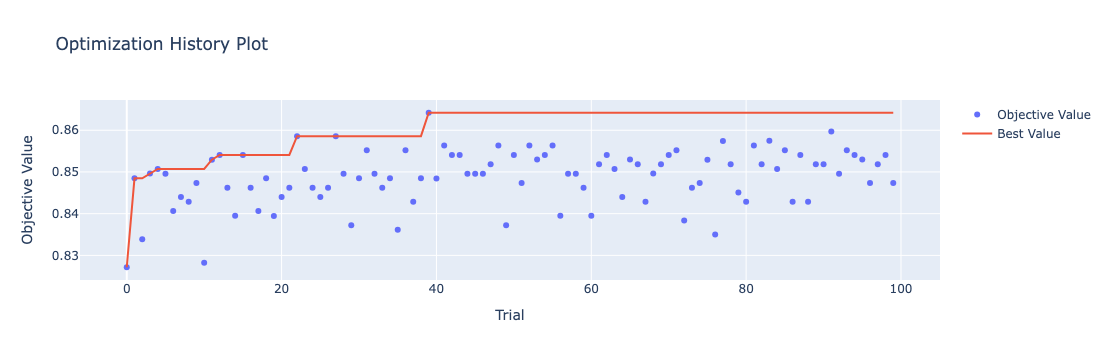

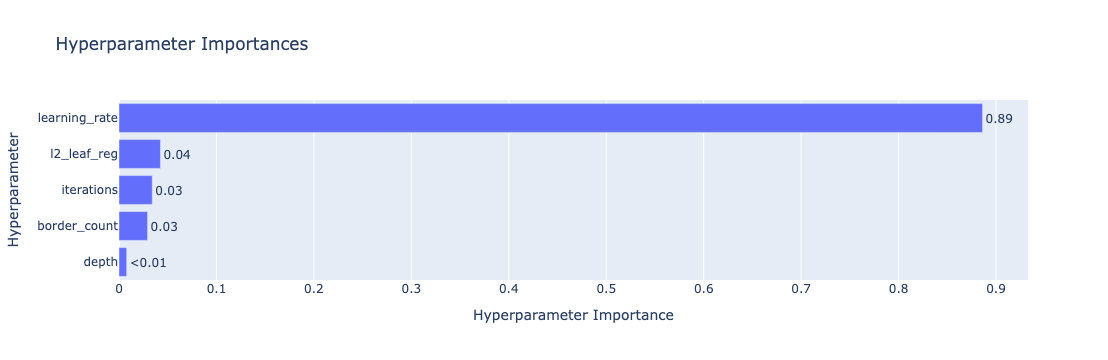

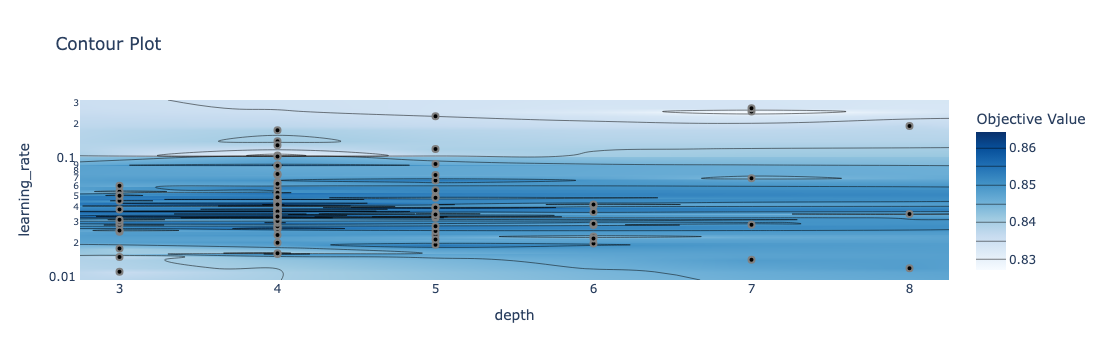

In [30]:
# Historia del progreso
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

# Importancia de cada hiperparámetro
fig = optuna.visualization.plot_param_importances(study)
fig.show()

# Contour plot: relación entre los 2 hiperparámetros más importantes
fig = optuna.visualization.plot_contour(study, params=['learning_rate', 'depth'])
fig.show()

In [31]:
# ===============================================
# Paso 7: Ensembling - Voting y Stacking
# ===============================================
from sklearn.ensemble import VotingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 1. Definimos modelos diversos (idealmente, los ya tuneados en el Paso 6)
models_for_ensemble = {
    'lr': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'rf': RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_split=5,
                                  random_state=42, n_jobs=-1),
    'xgb': XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='logloss', random_state=42),
    'lgbm': LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
                            num_leaves=15, subsample=0.8, colsample_bytree=0.8,
                            random_state=42, verbose=-1),
    'cb':  CatBoostClassifier(iterations=500, learning_rate=0.05, depth=4,
                               random_state=42, verbose=0),
}

# Envolvemos cada uno en pipeline con preprocesamiento
estimators = [(name, Pipeline([('prep', preprocessor), ('clf', m)]))
              for name, m in models_for_ensemble.items()]

# --- Voting soft ---
voting_soft = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)

# --- Stacking con Logistic Regression como meta-modelo ---
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    cv=5,
    n_jobs=-1,
    passthrough=False   # True = el meta-modelo también ve las features originales
)

# Evaluamos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Ensemble':<20} | {'Accuracy':>9} | {'Std':>7}")
print("-" * 44)
for name, ens in [('Voting soft', voting_soft), ('Stacking', stacking)]:
    scores = cross_val_score(ens, X_train, y, cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:<20} | {scores.mean():>9.4f} | {scores.std():>7.4f}")

Ensemble             |  Accuracy |     Std
--------------------------------------------


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

Voting soft          |    0.8485 |  0.0148


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_

Stacking             |    0.8530 |  0.0157


/Users/caneda/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [32]:
voting_weighted = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[1, 2, 3, 3, 4]  # LR=1, RF=2, XGB=3, LGBM=3, CB=4
)

In [33]:
cat_seeds = [CatBoostClassifier(iterations=500, random_state=s, verbose=0)
             for s in [42, 123, 456, 789, 2024]]